# 05 — Валидация сегментационной модели

Загружаем обученный `FiLMRoutedUNet3D` и прогоняем на всей val-выборке.
Цель: получить объективную статистику качества — Dice, BCE loss, voxel error rate —
с разбивкой по породе (Berea / BanderaBrown) и размеру куба (64 / 128 / 192).

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "utils").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Project root with src/utils was not found")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import utils.data as data_module
import utils.film_routing as film_module
import utils.losses as losses_module

data_module = importlib.reload(data_module)
film_module = importlib.reload(film_module)
losses_module = importlib.reload(losses_module)

DEFAULT_CUBE_SIZES = data_module.DEFAULT_CUBE_SIZES
BereaPatchDataset = data_module.BereaPatchDataset
FiLMRoutedUNet3D = film_module.FiLMRoutedUNet3D
dice_score_from_logits = losses_module.dice_score_from_logits

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_DIR = ROOT / "models"
print("ROOT:", ROOT, "device:", device)

ROOT: c:\Users\F\Desktop\ДЗ\ОАИП\micro_ct device: cuda


## 1. Параметры валидации

In [2]:
CHECKPOINT_PATH = MODEL_DIR / "film_routed_unet3d_best.pth"
CUBE_SIZES = list(DEFAULT_CUBE_SIZES)  # [64, 128, 192]
BATCH_SIZE = 1
NUM_WORKERS = 0
PIN_MEMORY = device == "cuda"

# Сколько val-батчей максимум (None = все). Быстрая оценка: первые 50.
MAX_VAL_BATCHES = None  # или 100 для быстрой проверки

print("Checkpoint:", CHECKPOINT_PATH)
print("Cube sizes:", CUBE_SIZES)
print("Device:", device)

Checkpoint: c:\Users\F\Desktop\ДЗ\ОАИП\micro_ct\models\film_routed_unet3d_best.pth
Cube sizes: [64, 128, 192]
Device: cuda


## 2. Загрузка модели

In [3]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
base_channels = int(checkpoint.get("base_channels", 16))
ctx_dim = int(checkpoint.get("ctx_dim", 64))
print(f"Loaded checkpoint: base_channels={base_channels}, ctx_dim={ctx_dim}")
print(f"Best val_loss={checkpoint['val_loss']:.4f}, val_dice={checkpoint['val_dice']:.4f} at epoch={checkpoint['epoch']}")

model = FiLMRoutedUNet3D(
    in_channels=1,
    out_channels=1,
    base_channels=base_channels,
    ctx_dim=ctx_dim,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded checkpoint: base_channels=16, ctx_dim=64
Best val_loss=0.0711, val_dice=0.9641 at epoch=10
Model parameters: 1,484,461


## 3. Загрузка val-датасета

Берём все породы (Berea, BanderaBrown) и все размеры кубов (64, 128, 192).
На валидации — без шума (noise_types=["none"]), без балансировки.

In [4]:
val_ds = BereaPatchDataset(
    ROOT,
    split="val",
    cube_size=CUBE_SIZES,
    use_raw_gray=False,
    noise_types=["none"],
    balance=False,
    samples_per_group=None,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Val dataset: {len(val_ds)} samples")
print()
print("Распределение по группам:")
display(val_ds.df.groupby(["rock", "cube_size"]).size().rename("count").reset_index())

Val dataset: 1928 samples

Распределение по группам:


,rock,cube_size,count
0,BanderaBrown,64,819
1,BanderaBrown,128,102
2,BanderaBrown,192,43
3,Berea,64,819
4,Berea,128,102
5,Berea,192,43


## 4. Инференс на val-выборке

Собираем для каждого куба:
- Dice score
- BCE loss
- Voxel error rate (доля несовпадающих вокселей)
- Порода, размер, координаты, пористость

In [5]:
results = []  # список словарей
bce_loss_fn = torch.nn.BCEWithLogitsLoss()

val_bar = tqdm(val_loader, desc="Validation")

with torch.no_grad():
    for batch_idx, batch in enumerate(val_bar):
        if MAX_VAL_BATCHES is not None and batch_idx >= MAX_VAL_BATCHES:
            break

        x = batch["x"].to(device)
        y = batch["y"].to(device)

        out = model(x, return_dict=True)
        logits = out["logits"]

        dice = float(dice_score_from_logits(logits, y).detach().cpu())
        bce_loss_val = float(bce_loss_fn(logits, y).detach().cpu())

        pred_mask = (torch.sigmoid(logits) >= 0.5).float()
        error_rate = float((pred_mask != y).float().mean().detach().cpu())

        rock = batch["rock"][0] if isinstance(batch["rock"], (list, tuple)) else str(batch["rock"])
        cube_size = int(batch["cube_size"][0].detach().cpu())
        coord = tuple(batch["coord"][0].detach().cpu().tolist())
        porosity = float(batch["porosity"][0].detach().cpu())

        results.append({
            "rock": rock,
            "cube_size": cube_size,
            "coord": coord,
            "porosity": porosity,
            "dice": dice,
            "bce_loss": bce_loss_val,
            "error_rate": error_rate,
        })

        # Сохраняем данные для визуализации худшего/лучшего
        if batch_idx == 0:
            first_x = x.detach().cpu()
            first_y = y.detach().cpu()
            first_logits = logits.detach().cpu()

        val_bar.set_postfix({"dice": f"{dice:.4f}", "error": f"{error_rate:.4f}"})

df = pd.DataFrame(results)
print(f"\nОбработано {len(df)} кубов")
print(f"Средний Dice: {df['dice'].mean():.4f} ± {df['dice'].std():.4f}")
print(f"Средняя ошибка: {df['error_rate'].mean():.4f} ± {df['error_rate'].std():.4f}")

Validation:   0%|          | 0/1928 [00:00<?, ?it/s]


Обработано 1928 кубов
Средний Dice: 0.9461 ± 0.0552
Средняя ошибка: 0.0217 ± 0.0170


## 5. Статистика по группам

In [6]:
print("=" * 60)
print("СТАТИСТИКА ПО ПОРОДАМ")
print("=" * 60)
rock_stats = df.groupby("rock")["dice"].agg(["mean", "std", "min", "max", "count"])
display(rock_stats.round(4))

print()
print("=" * 60)
print("СТАТИСТИКА ПО РАЗМЕРУ КУБА")
print("=" * 60)
size_stats = df.groupby("cube_size")["dice"].agg(["mean", "std", "min", "max", "count"])
display(size_stats.round(4))

print()
print("=" * 60)
print("СТАТИСТИКА ПО ПОРОДЕ × РАЗМЕР")
print("=" * 60)
cross_stats = df.groupby(["rock", "cube_size"])["dice"].agg(["mean", "std", "min", "max", "count"])
display(cross_stats.round(4))

СТАТИСТИКА ПО ПОРОДАМ


,mean,std,min,max,count
rock,,,,,
BanderaBrown,0.9517,0.0354,0.3159,0.9820,964
Berea,0.9405,0.0691,0.2449,0.9856,964



СТАТИСТИКА ПО РАЗМЕРУ КУБА


,mean,std,min,max,count
cube_size,,,,,
64,0.9427,0.0576,0.2449,0.9856,1638
128,0.9635,0.0378,0.6174,0.9846,204
192,0.9692,0.0157,0.8763,0.9848,86



СТАТИСТИКА ПО ПОРОДЕ × РАЗМЕР


mean     std     min     max  count
rock         cube_size                                       
BanderaBrown 64         0.9493  0.0355  0.3159  0.9820    819
             128        0.9636  0.0364  0.6174  0.9787    102
             192        0.9690  0.0168  0.8763  0.9800     43
Berea        64         0.9362  0.0727  0.2449  0.9856    819
             128        0.9635  0.0394  0.6254  0.9846    102
             192        0.9694  0.0148  0.9189  0.9848     43

## 6. Графики

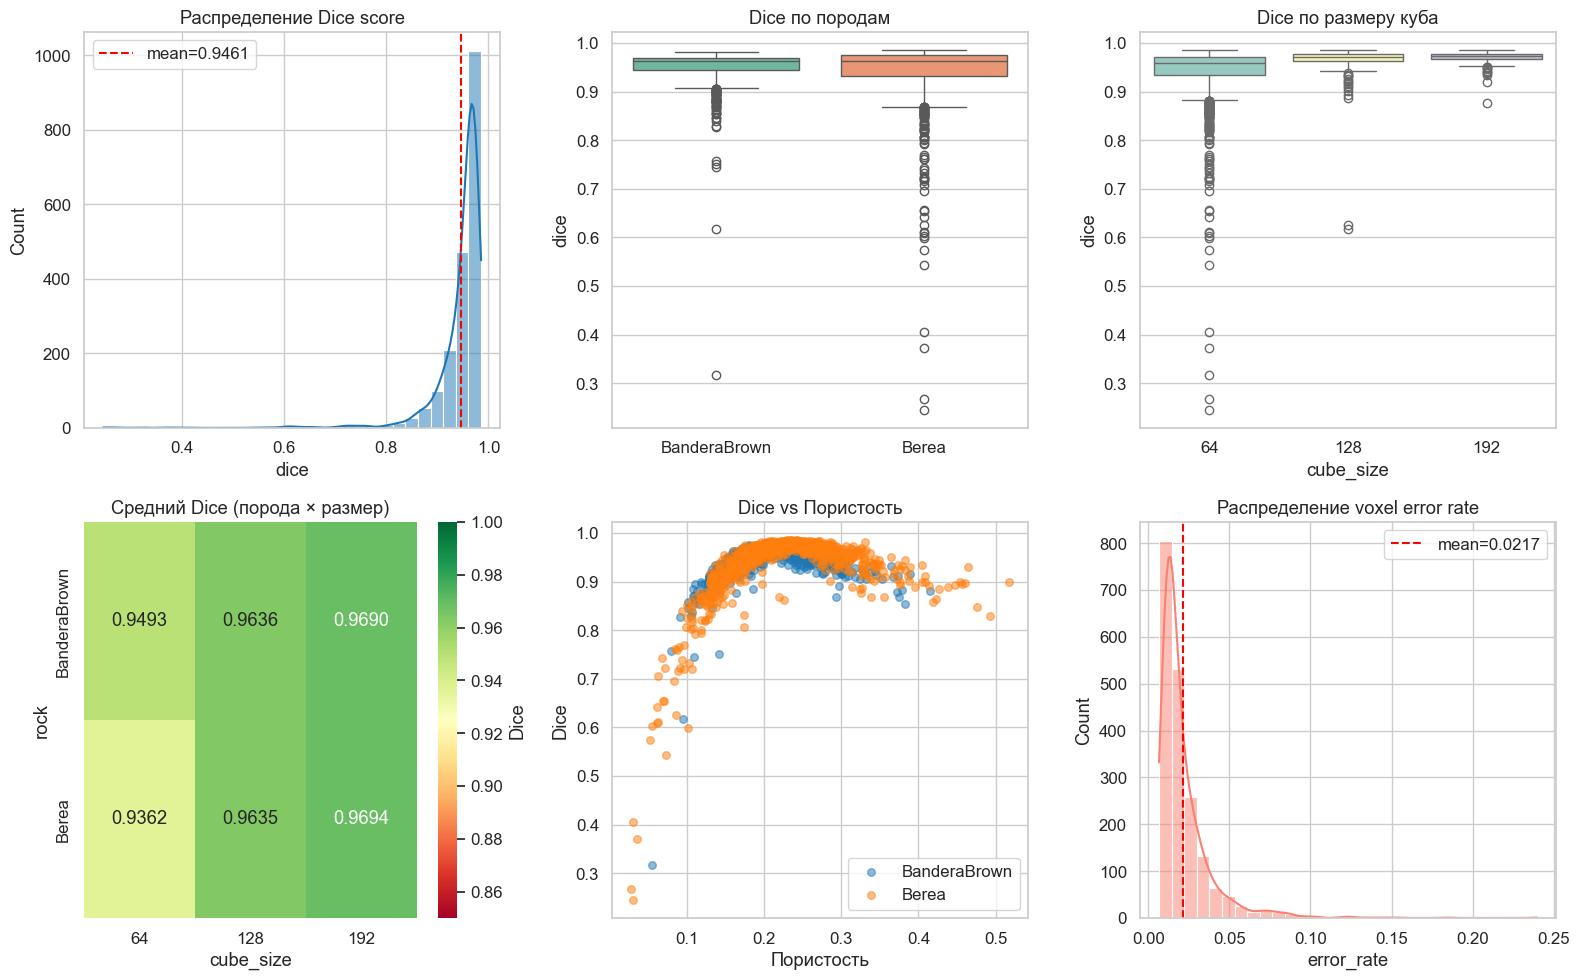

In [7]:
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6.1 Гистограмма Dice
ax = axes[0, 0]
sns.histplot(df, x="dice", bins=30, ax=ax, kde=True)
ax.axvline(df["dice"].mean(), color="red", linestyle="--", label=f"mean={df['dice'].mean():.4f}")
ax.set_title("Распределение Dice score")
ax.legend()

# 6.2 Box plot по породам
ax = axes[0, 1]
sns.boxplot(data=df, x="rock", y="dice", ax=ax, palette="Set2")
ax.set_title("Dice по породам")
ax.set_xlabel("")

# 6.3 Box plot по размеру куба
ax = axes[0, 2]
sns.boxplot(data=df, x="cube_size", y="dice", ax=ax, palette="Set3")
ax.set_title("Dice по размеру куба")

# 6.4 Heatmap порода × размер
ax = axes[1, 0]
pivot = df.pivot_table(values="dice", index="rock", columns="cube_size", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, vmin=0.85, vmax=1.0,
            cbar_kws={"label": "Dice"})
ax.set_title("Средний Dice (порода × размер)")

# 6.5 Dice vs Porosity
ax = axes[1, 1]
for rock_name in df["rock"].unique():
    subset = df[df["rock"] == rock_name]
    ax.scatter(subset["porosity"], subset["dice"], alpha=0.5, label=rock_name, s=30)
ax.set_xlabel("Пористость")
ax.set_ylabel("Dice")
ax.set_title("Dice vs Пористость")
ax.legend()

# 6.6 Гистограмма error_rate
ax = axes[1, 2]
sns.histplot(df, x="error_rate", bins=30, ax=ax, kde=True, color="salmon")
ax.axvline(df["error_rate"].mean(), color="red", linestyle="--", label=f"mean={df['error_rate'].mean():.4f}")
ax.set_title("Распределение voxel error rate")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Худшие и лучшие кубы

Показывает координаты (origin z,y,x) — их можно открыть в визуализаторе.

In [8]:
TOP_K = 10

print("=" * 60)
print(f"ТОП-{TOP_K} ХУДШИХ КУБОВ (по Dice)")
print("=" * 60)
worst = df.nsmallest(TOP_K, "dice")
display(worst[["rock", "cube_size", "coord", "dice", "error_rate", "porosity"]].reset_index(drop=True))

print()
print("=" * 60)
print(f"ТОП-{TOP_K} ЛУЧШИХ КУБОВ (по Dice)")
print("=" * 60)
best = df.nlargest(TOP_K, "dice")
display(best[["rock", "cube_size", "coord", "dice", "error_rate", "porosity"]].reset_index(drop=True))

ТОП-10 ХУДШИХ КУБОВ (по Dice)


,rock,cube_size,coord,dice,error_rate,porosity
0,Berea,64,"(448, 576, 320)",0.244892,0.184669,0.029945
1,Berea,64,"(512, 576, 320)",0.268250,0.152531,0.027958
2,BanderaBrown,64,"(64, 768, 0)",0.315905,0.239578,0.055317
3,Berea,64,"(832, 936, 0)",0.371324,0.122066,0.036049
4,Berea,64,"(0, 936, 448)",0.405719,0.088318,0.030159
5,Berea,64,"(256, 576, 704)",0.543256,0.123940,0.073708
6,Berea,64,"(936, 512, 448)",0.573286,0.077629,0.052158
7,Berea,64,"(512, 576, 512)",0.599523,0.135075,0.101120
8,Berea,64,"(128, 192, 936)",0.603259,0.072544,0.055153
9,Berea,64,"(512, 0, 640)",0.608448,0.078575,0.061054



ТОП-10 ЛУЧШИХ КУБОВ (по Dice)


,rock,cube_size,coord,dice,error_rate,porosity
0,Berea,64,"(320, 192, 64)",0.985641,0.006973,0.242321
1,Berea,64,"(768, 768, 64)",0.985173,0.006824,0.231441
2,Berea,64,"(192, 576, 896)",0.985164,0.006832,0.230221
3,Berea,64,"(448, 768, 128)",0.984918,0.007092,0.235298
4,Berea,64,"(768, 256, 320)",0.984885,0.007153,0.234825
5,Berea,192,"(0, 576, 0)",0.984845,0.007310,0.240978
6,Berea,64,"(936, 704, 128)",0.984627,0.007042,0.229691
7,Berea,128,"(768, 256, 384)",0.984613,0.007595,0.246141
8,Berea,64,"(896, 192, 384)",0.984548,0.007309,0.235283
9,Berea,64,"(896, 896, 128)",0.984536,0.007282,0.236774


## 8. Визуализация примеров сегментации (слайсы)

Показываем для лучшего, среднего и худшего куба:
- Input (серый)
- Ground truth (бинарная маска пор)
- Предсказание (probability map)
- Ошибки: FP — красный, FN — синий

⚠️ Внимание: из-за особенностей Jupyter, перезапустите ячейку если графики не отображаются.
   Если размер куба большой (192³) — рендеринг может быть медленным.

In [9]:
# Собираем данные для визуализации трёх примеров
examples = {}

worst_idx = df["dice"].idxmin()
best_idx = df["dice"].idxmax()
median_idx = df["dice"].sub(df["dice"].median()).abs().idxmin()

for label, idx in [("ХУДШИЙ", worst_idx), ("СРЕДНИЙ", median_idx), ("ЛУЧШИЙ", best_idx)]:
    row = df.iloc[idx]
    rock, cs = row["rock"], row["cube_size"]
    coord = row["coord"]
    
    # Находим этот сэмпл в датасете и получаем данные
    # Создаем dataset только для этого размера куба, чтобы получить точный срез
    ds_single = BereaPatchDataset(
        ROOT,
        split="val",
        cube_size=[cs],
        use_raw_gray=False,
        noise_types=["none"],
        balance=False,
        rocks=[rock],
        return_aux_targets=False,
    )
    
    found = False
    for sample_idx in range(len(ds_single)):
        sample = ds_single[sample_idx]
        sample_coord = tuple(sample["coord"].tolist())
        if sample_coord == coord:
            x_np = sample["x"][0].numpy()
            y_np = sample["y"][0].numpy()
            
            # Прогоняем через модель
            x_tensor = torch.from_numpy(x_np).float().unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(x_tensor, return_dict=True)
                prob = torch.sigmoid(out["logits"])[0, 0].detach().cpu().numpy()
            
            examples[label] = {
                "x": x_np,
                "y": y_np,
                "prob": prob,
                "dice": row["dice"],
                "rock": rock,
                "cube_size": cs,
                "coord": coord,
            }
            found = True
            break
    
    if not found:
        print(f"Не удалось найти сэмпл {label} (rock={rock}, coord={coord})")

print(f"Загружено примеров: {len(examples)}")
for label, data in examples.items():
    print(f"  {label}: {data['rock']} {data['cube_size']}³ coord={data['coord']} dice={data['dice']:.4f}")

Загружено примеров: 3
  ХУДШИЙ: Berea 64³ coord=(448, 576, 320) dice=0.2449
  СРЕДНИЙ: BanderaBrown 64³ coord=(0, 704, 256) dice=0.9623
  ЛУЧШИЙ: Berea 64³ coord=(320, 192, 64) dice=0.9856


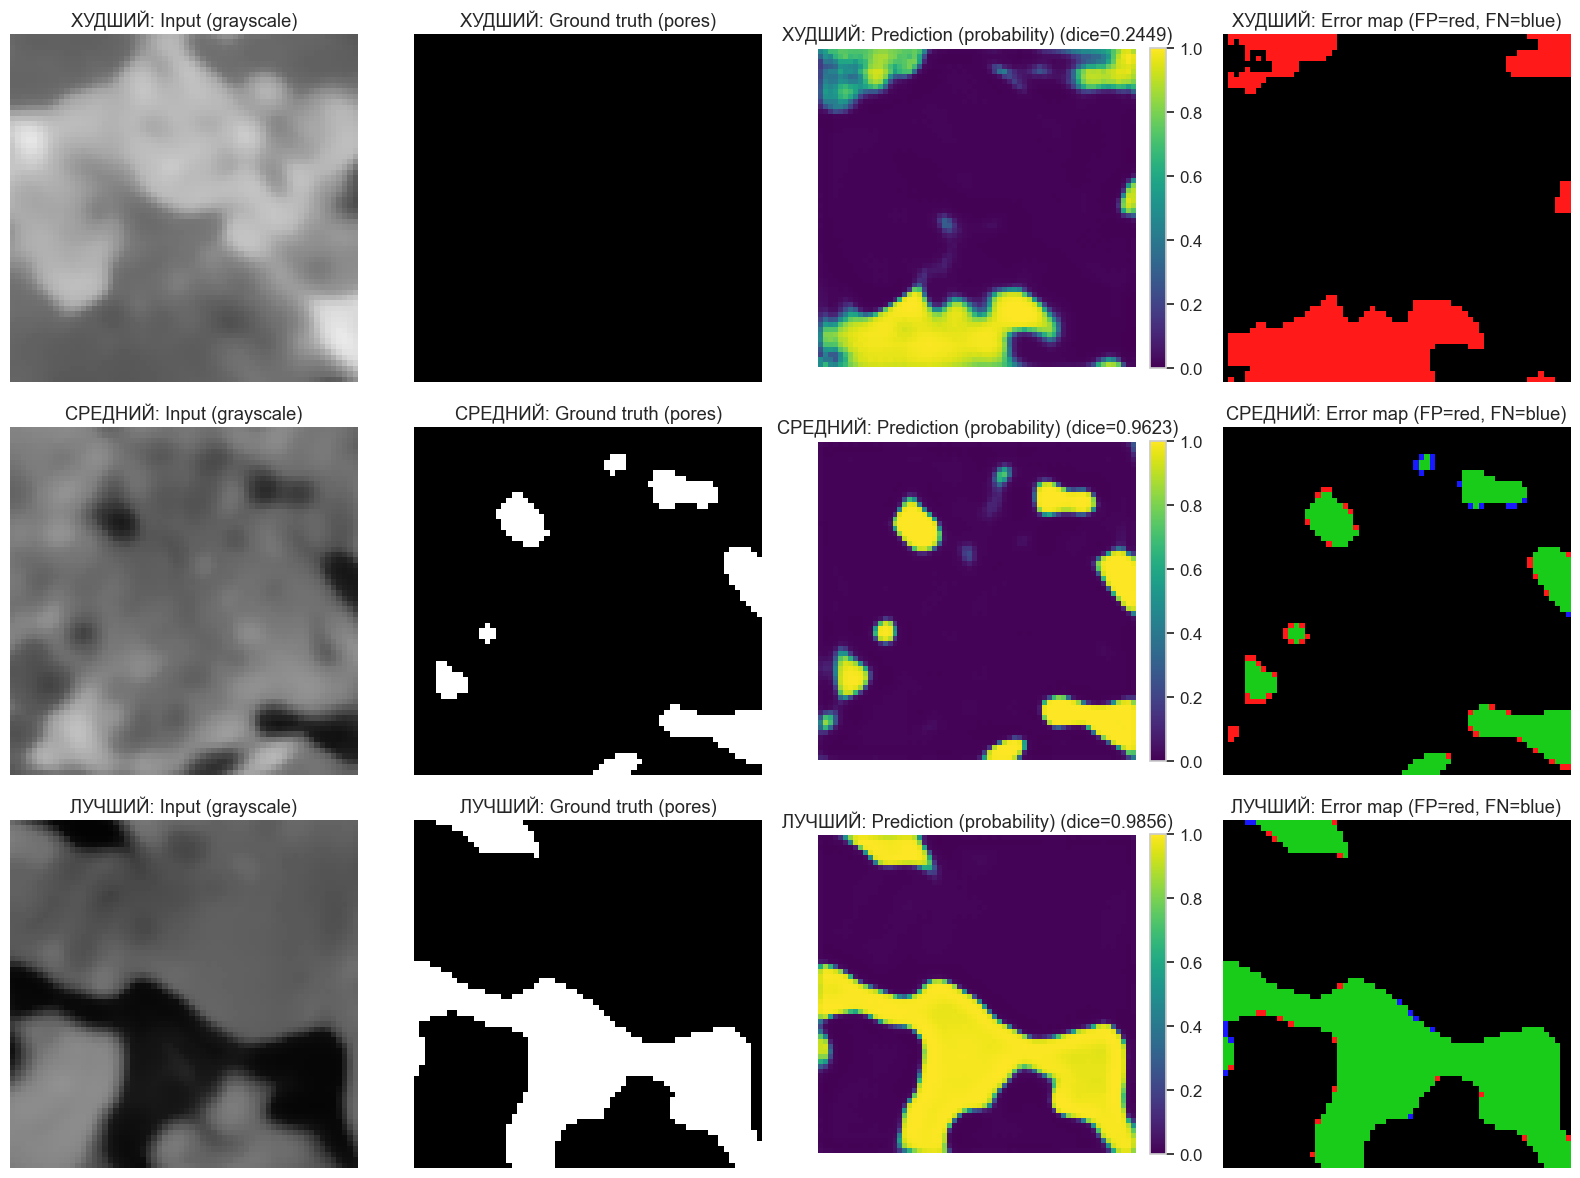

In [15]:
if len(examples) > 0:
    fig, axes = plt.subplots(len(examples), 4, figsize=(16, 4 * len(examples)))

    # Если пример один, axes будет одномерным — делаем двумерным
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    titles = [
        "Input (grayscale)",
        "Ground truth (pores)",
        "Prediction (probability)",
        "Error map (FP=red, FN=blue)"
    ]

    for row_idx, (label, data) in enumerate(examples.items()):
        x_np = data["x"]
        y_np = data["y"]
        prob = data["prob"]

        mid_z = x_np.shape[0] // 2

        input_slice = x_np[mid_z, :, :]
        gt_slice = y_np[mid_z, :, :]
        prob_slice = prob[mid_z, :, :]

        # ВАЖНО: приводим маски к boolean
        gt_mask = gt_slice >= 0.5
        pred_mask = prob_slice >= 0.5

        error_map = np.zeros((*gt_mask.shape, 3), dtype=np.float32)

        # FP: модель предсказала пору, а в GT её нет
        fp = pred_mask & (~gt_mask)
        error_map[fp] = [1.0, 0.1, 0.1]

        # FN: пора есть в GT, но модель её не предсказала
        fn = (~pred_mask) & gt_mask
        error_map[fn] = [0.1, 0.1, 1.0]

        # TP: правильно предсказанные поры
        tp = pred_mask & gt_mask
        error_map[tp] = [0.1, 0.8, 0.1]

        axes[row_idx, 0].imshow(input_slice, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 0].set_title(f"{label}: {titles[0]}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, 1].set_title(f"{label}: {titles[1]}")
        axes[row_idx, 1].axis("off")

        im = axes[row_idx, 2].imshow(prob_slice, cmap="viridis", vmin=0, vmax=1)
        axes[row_idx, 2].set_title(f"{label}: {titles[2]} (dice={data['dice']:.4f})")
        axes[row_idx, 2].axis("off")
        plt.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

        axes[row_idx, 3].imshow(error_map)
        axes[row_idx, 3].set_title(f"{label}: {titles[3]}")
        axes[row_idx, 3].axis("off")

    plt.tight_layout()
    plt.show()

## 9. Анализ router alpha

Проверяем, как FiLM-маршрутизатор распределяет веса между контекстными источниками.

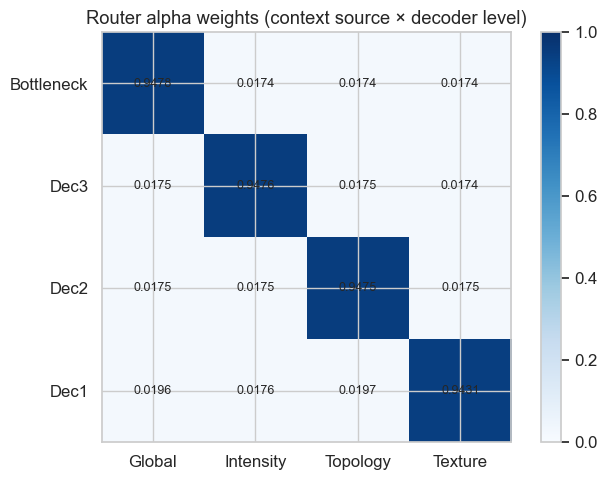

Наблюдение: alpha практически диагональная → router почти не использует контекст.
Это значит, что FiLM-маршрутизация не адаптируется под разные породы/размеры.
Модель работает как обычный U-Net с маленькими FiLM-модулями.


In [16]:
alpha = model.router.alpha().detach().cpu().numpy()
source_names = ["Global", "Intensity", "Topology", "Texture"]
level_names = ["Bottleneck", "Dec3", "Dec2", "Dec1"]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(alpha, cmap="Blues", vmin=0, vmax=1)

for i in range(alpha.shape[0]):
    for j in range(alpha.shape[1]):
        ax.text(j, i, f"{alpha[i, j]:.4f}", ha="center", va="center", fontsize=9)

ax.set_xticks(range(len(source_names)))
ax.set_xticklabels(source_names)
ax.set_yticks(range(len(level_names)))
ax.set_yticklabels(level_names)
ax.set_title("Router alpha weights (context source × decoder level)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Наблюдение: alpha практически диагональная → router почти не использует контекст.")
print("Это значит, что FiLM-маршрутизация не адаптируется под разные породы/размеры.")
print("Модель работает как обычный U-Net с маленькими FiLM-модулями.")

## 10. Итоговая сводка

Вывод: на каких данных модель хороша, а где нужно дообучение.

In [17]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)

overall_dice = df["dice"].mean()
print(f"Общий Dice: {overall_dice:.4f}")
print()

print("Dice по группам (порода × размер):")
pivot_summary = df.pivot_table(
    values="dice",
    index="rock",
    columns="cube_size",
    aggfunc=["mean", "std", "count"]
)
display(pivot_summary.round(4))

print()
print("Выводы:")
print()

# Анализ: на каких группах худший результат
group_means = df.groupby(["rock", "cube_size"])["dice"].mean()
worst_group = group_means.idxmin()
best_group = group_means.idxmax()

print(f"🔴 Самая сложная группа: {worst_group[0]} {worst_group[1]}³ (Dice={group_means.min():.4f})")
print(f"🟢 Самая лёгкая группа: {best_group[0]} {best_group[1]}³ (Dice={group_means.max():.4f})")

berea_dice = df[df["rock"] == "Berea"]["dice"].mean()
bandera_dice = df[df["rock"] == "BanderaBrown"]["dice"].mean()
print()
print(f"Berea: Dice = {berea_dice:.4f}")
print(f"BanderaBrown: Dice = {bandera_dice:.4f}")
print(f"Разница: {abs(berea_dice - bandera_dice):.4f}")

print()
print("Рекомендации:")
print("- Если разница между породами >0.02 → нужен лучший баланс данных")
print("- Если худшие кубы приходится на 192³ → увеличить долю 192³ в тренировке")
print("- Если все группы показывают Dice < 0.95 → проблема в архитектуре/гиперпараметрах")

ИТОГОВАЯ СВОДКА
Общий Dice: 0.9461

Dice по группам (порода × размер):


mean                     std                 count         
cube_size        64      128     192     64      128     192   64   128 192
rock                                                                       
BanderaBrown  0.9493  0.9636  0.9690  0.0355  0.0364  0.0168   819  102  43
Berea         0.9362  0.9635  0.9694  0.0727  0.0394  0.0148   819  102  43


Выводы:

🔴 Самая сложная группа: Berea 64³ (Dice=0.9362)
🟢 Самая лёгкая группа: Berea 192³ (Dice=0.9694)

Berea: Dice = 0.9405
BanderaBrown: Dice = 0.9517
Разница: 0.0112

Рекомендации:
- Если разница между породами >0.02 → нужен лучший баланс данных
- Если худшие кубы приходится на 192³ → увеличить долю 192³ в тренировке
- Если все группы показывают Dice < 0.95 → проблема в архитектуре/гиперпараметрах


## 11. (Опционально) Экспорт результатов в CSV

Сохраняет таблицу с метриками каждого куба для дальнейшего анализа.

In [ ]:
CSV_PATH = ROOT / "outputs" / "validation_results.csv"
df.to_csv(CSV_PATH, index=False)
print(f"Результаты сохранены: {CSV_PATH}")
display(df.head())